In [1]:
library(tidyverse)

library(grid)
library(gridExtra)
library(patchwork)

source("../evaluation_utils/plots_eda.R")
source("../evaluation_utils/evaluation_funcs.R")

Warning message:
“package ‘dplyr’ was built under R version 4.5.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: viridisLite

Loading required package: limma

Loading required package: BiocParallel


Attaching package: ‘variancePartition’


The following objects are masked from ‘package:limma’:

    eBayes, topTable




In [2]:
# 6 colors for 6 batches: DDA_APT, DDA_FDU, DDA_NVG, DIA_APT, DIA_BGI, DIA_FDU
cbPalette <- c("#CC79A7", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00")

# Load data

central_corrected === fedRBE corrected data

In [3]:
data_path <- "../evaluation_data/proteomics_multibatch/"
sites <- c("APT", "BGI", "FDU", "NVG")

# Load per-site before matrices and combine column-wise.
# All four sites share the same 3407-protein UNION index.
before_list <- lapply(sites, function(site) {
    read.csv(
        paste0(data_path, "before/", site, "/intensities_log_UNION.tsv"),
        sep = "\t", header = TRUE, row.names = 1, check.names = FALSE
    )
})
central_uncorrected <- do.call(cbind, before_list)

# Load and combine per-site design files for metadata.
# The 'batch' column encodes the measurement batch (e.g. DDA_APT, DIA_BGI);
# rename it to 'lab' for compatibility with plotting functions.
metadata_list <- lapply(sites, function(site) {
    read.csv(
        paste0(data_path, "before/", site, "/design.tsv"),
        sep = "\t", header = TRUE, check.names = FALSE
    )
})
metadata <- do.call(rbind, metadata_list) %>%
    rename(lab = batch)
rownames(metadata) <- metadata$file

central_corrected <- read.csv(
    paste0(data_path, "after/intensities_log_Rcorrected_UNION.tsv"),
    sep = "\t", header = TRUE, row.names = 1, check.names = FALSE
)
fed_corrected <- read.csv(
    paste0(data_path, "after/FedApp_corrected_data.tsv"),
    sep = "\t", header = TRUE, row.names = 1, check.names = FALSE
)

# Align all matrices to the metadata sample order
central_corrected   <- central_corrected[, rownames(metadata)]
central_uncorrected <- central_uncorrected[rownames(central_corrected), rownames(metadata)]
fed_corrected       <- fed_corrected[rownames(central_corrected), rownames(metadata)]

cat("Loaded data\n")
cat("Central uncorrected:", nrow(central_uncorrected), "rows\n")
cat("Central corrected:", nrow(central_corrected), "rows\n")
cat("Fed corrected:", nrow(fed_corrected), "rows\n")
cat("Sample metadata:", nrow(metadata), "rows\n\n")

Loaded data
Central uncorrected: 3407 rows
Central corrected: 3407 rows
Fed corrected: 3407 rows
Sample metadata: 72 rows



# Checks

## Diagnostic plots

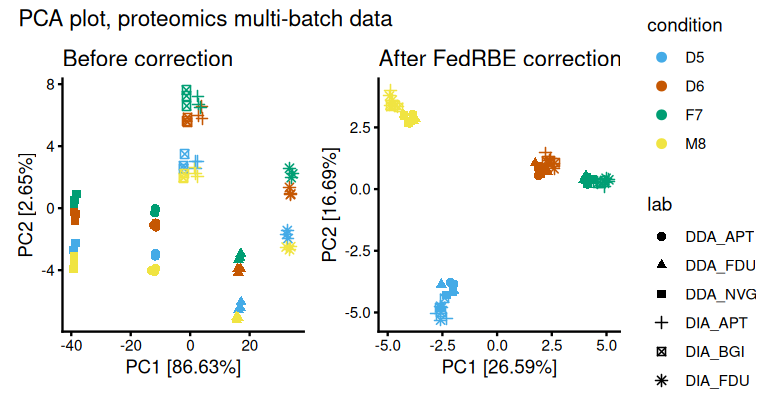

In [13]:
pca_plot_uncorrected <- pca_plot(central_uncorrected, metadata,
    title = "Before correction",
    quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
    show_legend = FALSE, cbPalette = c("#44abe7", "#c55702", "#009E73", "#F0E442"))
pca_plot_fed <- pca_plot(fed_corrected, metadata,
    title = "After FedRBE correction",
    quantitative_col_name = "file", col_col = "condition", shape_col = "lab",
    show_legend = TRUE, cbPalette = c("#44abe7", "#c55702", "#009E73", "#F0E442"))

layout <- (pca_plot_uncorrected + pca_plot_fed)
layout <- layout + plot_annotation("PCA plot, proteomics multi-batch data")
options(repr.plot.width = 6.5, repr.plot.height = 3.3)
layout

Warning message:
“Removed 37013 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 37013 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 37013 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 37013 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 37013 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 37013 rows containing non-finite outside the scale range
(`stat_summary()`).”


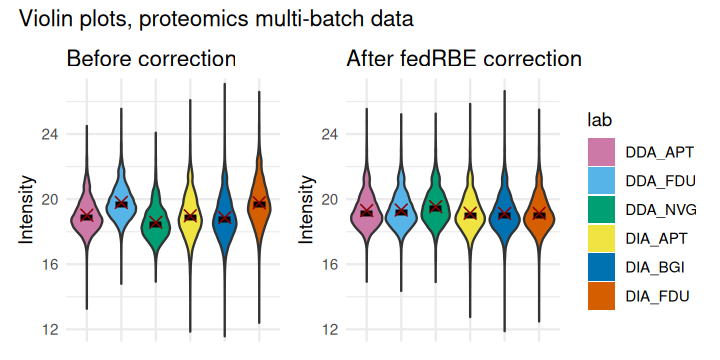

In [5]:
y_min <- min(central_uncorrected, fed_corrected, na.rm = TRUE)
y_max <- max(central_uncorrected, fed_corrected, na.rm = TRUE)
y_limits <- c(y_min, y_max)

boxplots_uncorrected <- boxplot_plot_groupped(central_uncorrected, metadata,
    title = "Before correction",
    quantitativeColumnName = "file",
    color_col = "lab", remove_xnames = TRUE, show_legend = FALSE,
    y_limits = y_limits, cbPalette = cbPalette)

boxplots_fed <- boxplot_plot_groupped(fed_corrected, metadata,
    title = "After fedRBE correction",
    quantitativeColumnName = "file",
    color_col = "lab", remove_xnames = TRUE,
    y_limits = y_limits, cbPalette = cbPalette)

layout <- (boxplots_uncorrected + boxplots_fed)
layout <- layout + plot_annotation("Violin plots, proteomics multi-batch data")
options(repr.plot.width = 6, repr.plot.height = 3)
layout

## Linear model per variable

Following batch effect correction, the percentage of variance explained by the condition should be greater than the batch.

In [6]:
library(variancePartition)

In [7]:
form <- ~ condition + lab

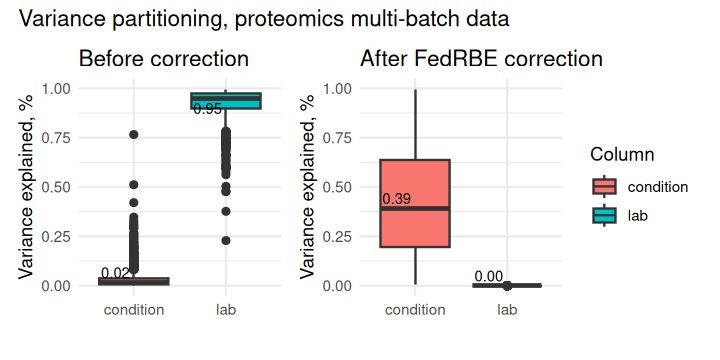

In [8]:
lmpv_plot_fed <- lmpv_plot(fed_corrected, metadata,
    title = "After FedRBE correction", form = form)
lmpv_plot_uncorrected <- lmpv_plot(central_uncorrected, metadata,
    title = "Before correction", show_legend = FALSE, form = form)

layout <- (lmpv_plot_uncorrected + lmpv_plot_fed)
layout <- layout + plot_annotation("Variance partitioning, proteomics multi-batch data")
options(repr.plot.width = 6, repr.plot.height = 3)
layout

# Session info

In [9]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /home/yuliya-cosybio/miniforge3/envs/fedRBE/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] variancePartition_1.40.1 BiocParallel_1.44.0      limma_3.66.0            
 [4] viridis_0.6.5            viridisLite_0.4.3        ggsci_4.2.0             
 [7] umap_0.2.10.0            patchwork_1.3.2      